In [1]:
'''
Simulation of MECT phantoms
'''

'\nSimulation of MECT phantoms\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [3]:
# load material attenuation data
min_kev = 30
max_kev = 120

df_att, dict_density = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=np.arange(min_kev, max_kev + 1, 1),
    return_density=True
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=np.arange(min_kev, max_kev + 1, 1)
)

df_att['true_water'] = df_water['mu']
dict_density['true_water'] = 1.0

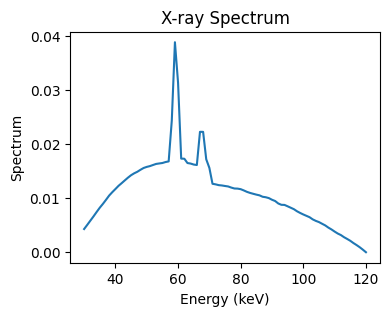

In [4]:
# load spectrum
df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))
df_spec = df_spec[(df_spec['Energy_keV'] >= min_kev) & (df_spec['Energy_keV'] <= max_kev)].reset_index(drop=True)
spectrum = df_spec['Photons'].values
spectrum = spectrum / np.sum(spectrum)  # normalize to sum to 1

df_spec = pd.DataFrame({
    'energy': df_spec['Energy_keV'],
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

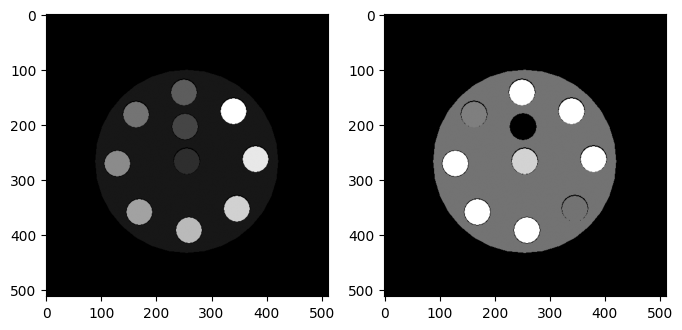

In [5]:
# load phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 2, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)
plt.show()


In [6]:
# load geometry
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = mask.shape[-1]
geo.ny = mask.shape[-2]
geo.nz = mask.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
# geo.nu *= 2
# geo.du /= 2
# geo.nview = 720
# geo.off_u = 0
# leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()


======== CT Parallel-Beam Geometry ========
number of angles: 1440
number of detector elements (rows, cols): 1 x 878
angular range: 360.000000 degrees
detector pixel size: 5.656000 mm x 0.351570 mm
center detector pixel: 0.000000, 445.750000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on device 0
GPU with least amount of memory: 35.170753 GB



True

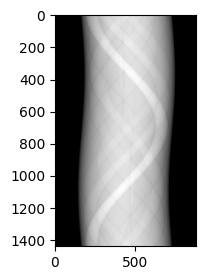

In [7]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# prjs = np.sum(prjs_materials, axis=0)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    # material = 'water'
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# composite the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)
# prjs_poly = -np.log(np.sum(np.exp(-prjs[..., None] * df_att['water'].values) * spectrum, axis=-1)).astype(np.float32)

plt.figure(figsize=(4, 3))
plt.imshow(prjs_poly[:, 0, :], 'gray')


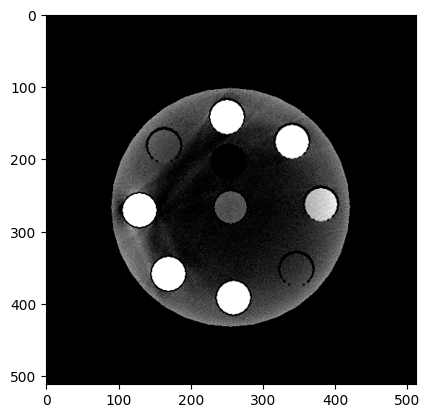

In [8]:
# reconstruction
recon_poly = leapct.FBP(prjs_poly)
plt.imshow(recon_poly[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

Fitted water attenuation: 0.019770, True water attenuation at 60keV: 0.020590
[ 9.47615279e-01  1.46685734e-02 -6.09879097e-04]


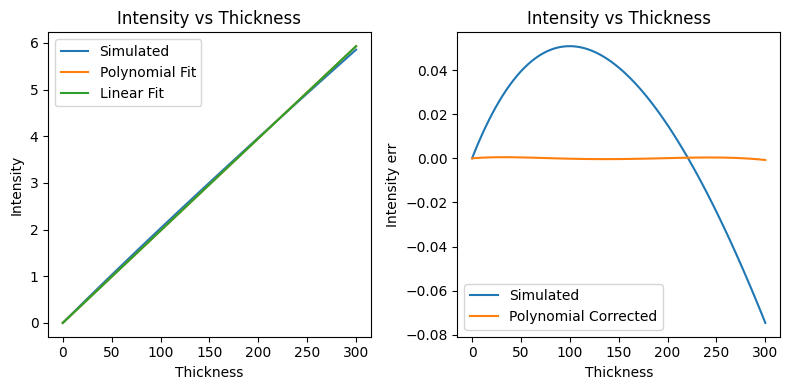

In [71]:
# test polynomial BHC using 30cm of water phantom
thicknesses = np.linspace(0, 300, 100)  # mm
attenuation = df_att['water'].values * thicknesses[:, None]
intensity = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
intensity[intensity < 0] = 0

# expected water attenuation: fit with y = kx
water_att = np.linalg.lstsq(thicknesses[:, None], intensity, rcond=None)[0][0]
print(f'Fitted water attenuation: {water_att:.6f}, True water attenuation at 60keV: {mu_water_60:.6f}')

# use 3-order polynomial fit without intercept
order = 3
A = np.vstack([intensity**i for i in range(1, order + 1)]).T
b = water_att * thicknesses
coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
print(coeffs)

# apply polynomial BHC
intensity_fit = np.sum(coeffs[:, None] * np.vstack([intensity**i for i in range(1, order + 1)]), axis=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity_fit, label='Polynomial Fit')
plt.plot(thicknesses, water_att * thicknesses, label='Linear Fit')
plt.xlabel('Thickness')
plt.ylabel('Intensity')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - water_att * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity_fit - water_att * thicknesses, label='Polynomial Corrected')
plt.xlabel('Thickness')
plt.ylabel('Intensity err')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.show()

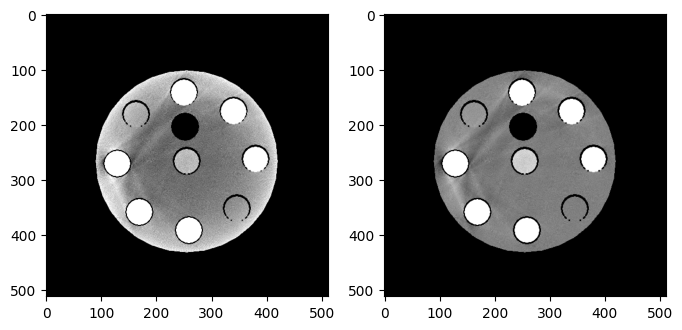

In [72]:
# apply correction to the projection data
prjs_fit = np.sum(coeffs[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit = additional_fbp_filter(prjs_fit)
recon_fit = leapct.FBP(prjs_fit)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_poly[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)

In [73]:
# convert recon_fit to HU and save nii
# recon_fit_hu = (recon_fit / water_att * 1000 - 1000).astype(np.int16)
# sitk_recon = sitk.GetImageFromArray(recon_fit_hu)
# sitk_recon.SetSpacing(sitk_mask.GetSpacing())
# sitk_recon.SetOrigin(sitk_mask.GetOrigin())
# sitk_recon.SetDirection(sitk_mask.GetDirection())
# sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, 'recon_fit.nii.gz'))

In [74]:
# solve for y = sum_i (c_i * p^i), where p = -log(sum_j (s_j * exp(-attenuation_j)))

attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
attenuation = attenuation.reshape([-1, attenuation.shape[-1]]).astype(np.float32)

# keep only the non-air rows
inds = attenuation.max(axis=1) > 1e-4
material_matrix = np.exp(-attenuation[inds])

y = prjs_fit.reshape(-1)[inds]

In [75]:
poly_order = 3

s = spectrum.copy()
fp = -np.log(material_matrix @ s)

# fit for the coefficients
c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

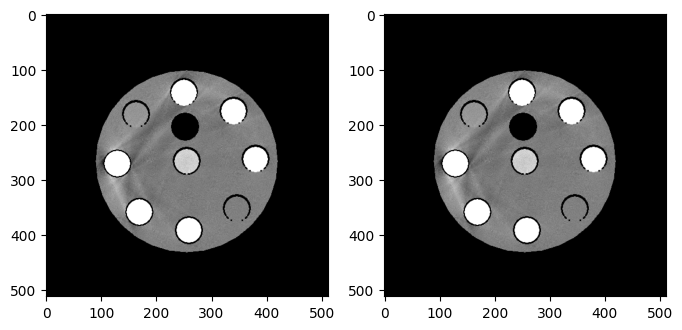

In [76]:
prjs_fit_solved = np.sum(c[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit_solved = additional_fbp_filter(prjs_fit_solved)
recon_fit_solved = leapct.FBP(prjs_fit_solved)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_fit[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit_solved[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)

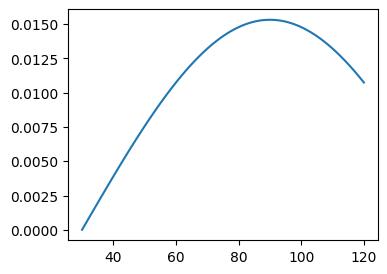

In [77]:
def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

u0 = 90
std = 60
u = gaussian(df_att['energy'].values, u0, std)
u = u - u.min()
u = u / np.sum(u)

plt.figure(figsize=(4, 3))
plt.plot(df_att['energy'], u)

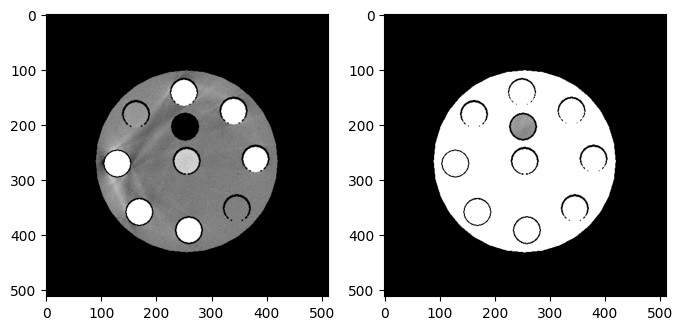

In [78]:
fp = -np.log(material_matrix @ u)

# fit for the coefficients
c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

prjs_fit_solved_2 = np.sum(c[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit_solved_2 = additional_fbp_filter(prjs_fit_solved_2)
recon_fit_solved_2 = leapct.FBP(prjs_fit_solved_2)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_fit_solved[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit_solved_2[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)

In [79]:
def poly_forward_with_bhc(s, c, material_matrix):
    '''
    s: (n_energy,) spectrum logits before softmax
    c: (poly_order,) polynomial coefficients
    material_matrix: (n_samples, n_energy) the effective attenuation of each sample at each energy
    '''
    # softmax to ensure positivity and sum to 1
    s = np.exp(s) / np.sum(np.exp(s))

    fp = -np.log(material_matrix @ s)
    return np.sum(c[:, None] * np.array([fp**i for i in range(1, len(c) + 1)]), axis=0)


def derivative_poly_forward_with_bhc(s, c, material_matrix):
    '''
    derivative of poly_forward_with_bhc with respect to logits s
    '''
    softmax_s = np.exp(s) / np.sum(np.exp(s))
    att_matrix = material_matrix @ softmax_s  # (n_samples,)

    poly_term = np.sum(c[:, None] * np.array([i * (-np.log(att_matrix))**(i-1) for i in range(1, len(c) + 1)]), axis=0)  # (n_samples,)
    d_fp_d_s = 1 / (-att_matrix[:, None]) * (material_matrix - att_matrix[:, None]) * softmax_s[None, :]  # (n_samples, n_energy)

    return poly_term[:, None] * d_fp_d_s


def mse_loss(s, c, material_matrix, y):
    '''
    MSE loss between poly_forward_with_bhc and y
    '''
    pred = poly_forward_with_bhc(s, c, material_matrix)
    return np.mean((pred - y)**2)


def derivative_mse_loss_with_respect_to_s(s, c, material_matrix, y):
    '''
    derivative of MSE loss with respect to logits s
    '''
    pred = poly_forward_with_bhc(s, c, material_matrix)
    d_pred_d_s = derivative_poly_forward_with_bhc(s, c, material_matrix)
    return 2 * np.sum((pred - y)[:, None] * d_pred_d_s, axis=0) / len(y)

In [80]:
# test the gradient with known coeffs
sampling_factor = 5
# s0 = np.ones_like(spectrum)
s0 = np.log(u + 1e-4)

s0 = s0[::sampling_factor]
mat_matrix_sparse = material_matrix[:, ::sampling_factor]
# y = prjs_poly.reshape(-1)[inds]

s = scipy.optimize.minimize(
    fun=mse_loss,
    x0=s0,
    args=(coeffs, mat_matrix_sparse, y),
    jac=derivative_mse_loss_with_respect_to_s,
    method='L-BFGS-B',
    options={'maxiter': 20, 'disp': True}
)


In [81]:
s

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 7.237456945775235e-05
        x: [-9.169e+00 -5.313e+00 ... -5.273e+00 -5.368e+00]
      nit: 15
      jac: [-7.903e-08 -1.299e-06 ...  9.618e-07  1.283e-06]
     nfev: 18
     njev: 18
 hess_inv: <19x19 LbfgsInvHessProduct with dtype=float64>

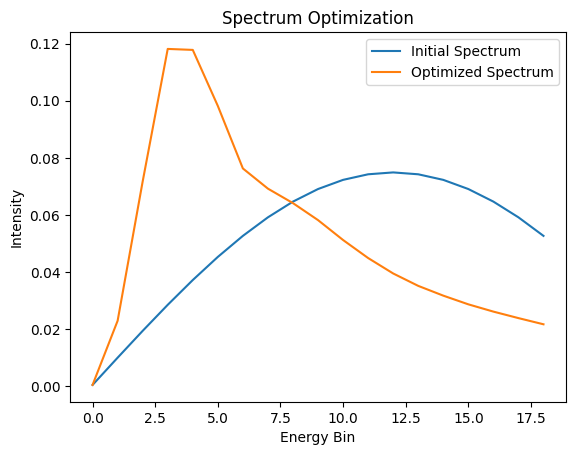

In [82]:
spectrum0 = np.exp(s0) / np.sum(np.exp(s0))
spectrum_fit = np.exp(s.x) / np.sum(np.exp(s.x))

plt.plot(spectrum0, label='Initial Spectrum')
plt.plot(spectrum_fit, label='Optimized Spectrum')
plt.xlabel('Energy Bin')
plt.ylabel('Intensity')
plt.title('Spectrum Optimization')
plt.legend()
plt.show()

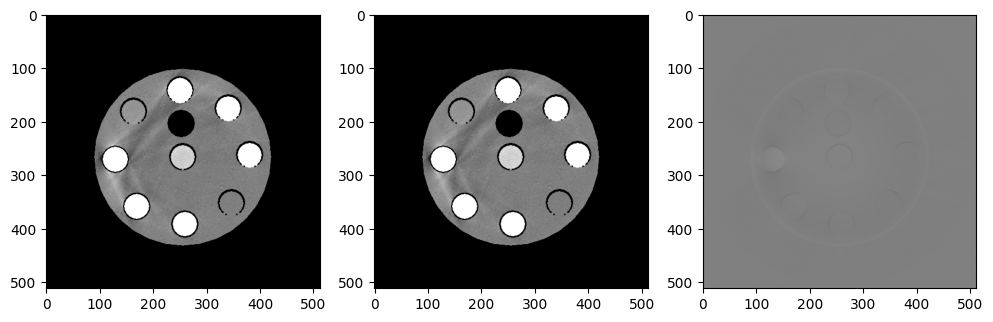

In [83]:
fp = -np.log(mat_matrix_sparse @ spectrum_fit)

# fit for the coefficients
c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

prjs_fit_solved_2 = np.sum(c[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit_solved_2 = additional_fbp_filter(prjs_fit_solved_2)
recon_fit_solved_2 = leapct.FBP(prjs_fit_solved_2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_fit[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 3, 2)
plt.imshow(recon_fit_solved_2[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 3, 3)
plt.imshow(recon_fit_solved_2[0] - recon_fit[0], cmap='gray', vmin=-0.001, vmax=0.001)

[ 0.9445293   0.01676134 -0.00095535]


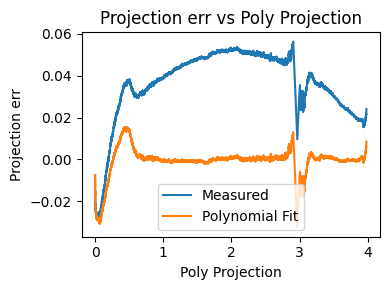

In [89]:
# fit coefficients with water-only projections(water, water_base, true_water, brain, adipose)
water_materials = ['water', 'water_base', 'true_water', 'brain', 'adipose']
df_mask_exclusion = df_mask[~df_mask['Material'].isin(water_materials)].copy()
prjs_exclusion_mask = np.where(np.sum(prjs_materials[df_mask_exclusion.index] , axis=0), 1, 0)

df_mask_inclusion = df_mask[df_mask['Material'].isin(water_materials)].copy()
densities = np.array([dict_density[mat] for mat in df_mask_inclusion['Material']])
prjs_thickness = np.sum(prjs_materials[df_mask_inclusion.index] * densities[:, None, None, None], axis=0)

# valid data for curve fitting
inds = np.where((prjs_thickness > 1e-4) & (prjs_exclusion_mask == 0))

# get the corresponding projection data
measured_prjs_poly = np.sort(prjs_poly[inds])
measured_prjs_fit = np.sort(prjs_fit[inds])

# polynomial fit
order = 3
fit_coeffs = np.linalg.lstsq(np.vstack([measured_prjs_poly**i for i in range(1, order + 1)]).T, measured_prjs_fit, rcond=None)[0]
print(fit_coeffs)

# apply polynomial BHC
intensity_fit = np.sum(fit_coeffs[:, None] * np.vstack([measured_prjs_poly**i for i in range(1, order + 1)]), axis=0)

plt.figure(figsize=(4, 3))
plt.plot(measured_prjs_poly, measured_prjs_poly - measured_prjs_fit, label='Measured')
plt.plot(measured_prjs_poly, intensity_fit - measured_prjs_fit, label='Polynomial Fit')
plt.xlabel('Poly Projection')
plt.ylabel('Projection err')
plt.title('Projection err vs Poly Projection')
plt.legend()
plt.tight_layout()

In [106]:
# joint estimation of spectrum and polynomial coefficients
sampling_factor = 5
n_outer_iter = 20
n_inner_iter = 20

s0 = np.ones_like(spectrum)
s0 = s0[::sampling_factor]
mat_matrix_sparse = material_matrix[:, ::sampling_factor]

# initialize spectrum with c = [1, 0, 0]
res = scipy.optimize.minimize(
    fun=mse_loss,
    x0=s0,
    args=(fit_coeffs, mat_matrix_sparse, y),
    jac=derivative_mse_loss_with_respect_to_s,
    method='L-BFGS-B',
    options={'maxiter': n_inner_iter, 'disp': True}
)
s = res.x

for i_outer in range(n_outer_iter):
    print(f'Outer iteration {i_outer + 1}/{n_outer_iter}')

    # solve for polynomial coefficients with current spectrum
    current_spectrum = np.exp(s) / np.sum(np.exp(s))
    fp = -np.log(mat_matrix_sparse @ current_spectrum)
    c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

    # optimize spectrum with current polynomial coefficients
    res = scipy.optimize.minimize(
        fun=mse_loss,
        x0=s0,
        args=(c, mat_matrix_sparse, y),
        jac=derivative_mse_loss_with_respect_to_s,
        method='L-BFGS-B',
        options={'maxiter': n_inner_iter, 'disp': True}
    )

    print(f'Current coefficients: {c}')
    print(res)

    s = res.x

Outer iteration 1/20
Current coefficients: [ 9.44873697e-01  1.59896442e-02 -7.65876833e-04]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 6.79984318160074e-05
        x: [ 1.038e-01  6.952e-01 ...  1.821e-01  6.966e-02]
      nit: 13
      jac: [ 7.133e-07  1.958e-06 ... -1.392e-06 -1.259e-06]
     nfev: 15
     njev: 15
 hess_inv: <19x19 LbfgsInvHessProduct with dtype=float64>
Outer iteration 2/20
Current coefficients: [ 9.44288627e-01  1.62275517e-02 -7.85724820e-04]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 6.923667563796692e-05
        x: [ 2.004e-01  7.534e-01 ...  2.252e-01  1.204e-01]
      nit: 11
      jac: [ 5.226e-06  5.663e-06 ...  3.803e-06  3.958e-06]
     nfev: 13
     njev: 13
 hess_inv: <19x19 LbfgsInvHessProduct with dtype=float64>
Outer iteration 3/20
Current coefficients: [ 9.41941375e-01  1.68769221e-02 -7.82419153e-04]
  message: CONVERGENCE: NORM OF PR

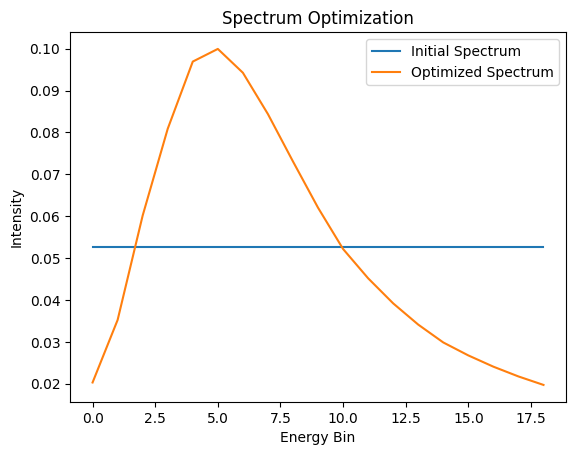

In [107]:
spectrum0 = np.exp(s0) / np.sum(np.exp(s0))
spectrum_fit = np.exp(s) / np.sum(np.exp(s))

plt.plot(spectrum0, label='Initial Spectrum')
plt.plot(spectrum_fit, label='Optimized Spectrum')
plt.xlabel('Energy Bin')
plt.ylabel('Intensity')
plt.title('Spectrum Optimization')
plt.legend()
plt.show()

9.67333e-06


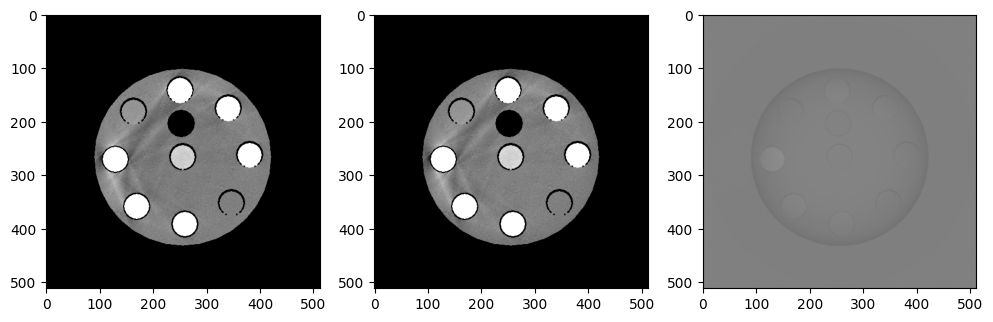

In [108]:
fp = -np.log(mat_matrix_sparse @ spectrum_fit)

# fit for the coefficients
c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

prjs_fit_solved_3 = np.sum(c[:, None, None, None] * np.array([prjs_poly**i for i in range(1, order + 1)]), axis=0).astype(np.float32)
prjs_fit_solved_3 = additional_fbp_filter(prjs_fit_solved_3)
recon_fit_solved_3 = leapct.FBP(prjs_fit_solved_3)

print(np.mean(np.abs(recon_fit_solved_3 - recon_fit)))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_fit[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 3, 2)
plt.imshow(recon_fit_solved_3[0], cmap='gray', vmin=water_att - 0.001, vmax=water_att + 0.001)
plt.subplot(1, 3, 3)
plt.imshow(recon_fit_solved_3[0] - recon_fit[0], cmap='gray', vmin=-0.001, vmax=0.001)